# Taller — Predicción de accidentalidad en Medellín

Grupo 3:
- **Daniel Pareja**
- **Sebastián Ruiz**
- **David Gómez**
- **Andrés Velasco**
- **Juan Morales**

**Profesor: Pablo Saldarriaga**

Flujo: `SQLite → EDA → Calidad → Features → Modelado → Métricas → Caso de uso`

Notebook portable: sin rutas absolutas, datos descargados automáticamente vía `gdown`.

## 0. Configuración global

In [ ]:
# --- Librerías estándar ---
import sqlite3
import gc
import warnings
import os

# --- Análisis de datos ---
import pandas as pd
import numpy as np
import holidays
import psutil

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelado ---
import joblib
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, fbeta_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

# --- Constantes globales ---
RANDOM_STATE = 42
DB_PATH      = 'accidentes.sqlite'
UNDERSAMPLE_RATIO = 10   # 1 positivo : 10 negativos en train

# Carpetas de salida (rutas relativas)
for folder in ['modelos', 'figuras', 'checkpoints']:
    os.makedirs(folder, exist_ok=True)

print('Configuración lista.')

Configuración lista.


In [ ]:
# Descarga automática de datos vía gdown (sin depender de Google Drive personal)
import subprocess
FILE_ID = '1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU'
if not os.path.exists(DB_PATH):
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(id=FILE_ID, output=DB_PATH, quiet=False)
    print(f'Base de datos descargada: {DB_PATH}')
else:
    print(f'Base de datos ya existe: {DB_PATH}')

Downloading...
From (original): https://drive.google.com/uc?id=1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU
From (redirected): https://drive.google.com/uc?id=1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU&confirm=t&uuid=a792fad2-4eba-4fee-ac6b-afc0c421025f
To: /content/accidentes.sqlite
100%|██████████| 1.19G/1.19G [00:11<00:00, 101MB/s]

Base de datos descargada: accidentes.sqlite


In [ ]:
def monitor_memoria():
    """Imprime el uso actual de RAM del sistema."""
    m = psutil.virtual_memory()
    print(f'RAM total: {m.total/1e9:.1f} GB | Usada: {m.used/1e9:.1f} GB | Libre: {m.available/1e9:.1f} GB ({m.percent}%)')

monitor_memoria()

RAM total: 13.6 GB | Usada: 1.7 GB | Libre: 11.6 GB (14.8%)


## 1. Carga de datos

In [ ]:
def cargar_tablas_sqlite(db_path):
    """
    Carga las tres tablas del taller desde SQLite.

    Args:
        db_path (str): ruta al archivo .sqlite
    Returns:
        Tupla (raw_accidentes, accidentes, clima) como DataFrames con TW parseado.
    """
    con = sqlite3.connect(db_path)
    raw = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
    acc = pd.read_sql('SELECT * FROM accidentes',     con, parse_dates=['TW'])
    cli = pd.read_sql('SELECT * FROM clima',          con, parse_dates=['TW'])
    con.close()
    return raw, acc, cli

raw_accidentes, accidentes, clima = cargar_tablas_sqlite(DB_PATH)
print(f'raw_accidentes: {raw_accidentes.shape}')
print(f'accidentes:     {accidentes.shape}')
print(f'clima:          {clima.shape}')

raw_accidentes: (125122, 22)
accidentes:     (120587, 8)
clima:          (7991780, 15)


In [ ]:
def optimizar_tipos(clima, accidentes):
    """
    Reduce uso de memoria convirtiendo tipos de datos.
    - Variables climáticas float64 → float32 (~50% menos RAM).
    - BARRIO → category en ambas tablas.
    """
    for col in clima.select_dtypes('float64').columns:
        clima[col] = clima[col].astype('float32')
    clima['BARRIO']     = clima['BARRIO'].astype('category')
    accidentes['BARRIO'] = accidentes['BARRIO'].astype('category')
    return clima, accidentes

clima, accidentes = optimizar_tipos(clima, accidentes)
monitor_memoria()

RAM total: 13.6 GB | Usada: 8.0 GB | Libre: 5.3 GB (61.2%)


## 2. Calidad de datos

In [ ]:
def diagnosticar_tabla(nombre, df):
    """Imprime shape, tipos y conteo de faltantes de una tabla."""
    print(f'\n=== {nombre} === shape: {df.shape}')
    faltantes = df.isna().sum()
    faltantes = faltantes[faltantes > 0]
    if len(faltantes):
        print('Faltantes:')
        print((faltantes / len(df) * 100).round(2).to_string())
    else:
        print('Sin faltantes.')

for nombre, tabla in [('raw_accidentes', raw_accidentes), ('accidentes', accidentes), ('clima', clima)]:
    diagnosticar_tabla(nombre, tabla)


=== raw_accidentes === shape: (125122, 22)
Faltantes:
RADICADO       0.00
DISENO         0.34
MES_NOMBRE    66.13

=== accidentes === shape: (120587, 8)
Sin faltantes.

=== clima === shape: (7991780, 15)
Faltantes:
summary                 6.87
icon                    6.87
precipIntensity         6.85
precipProbability       6.85
temperature             0.01
apparentTemperature     0.01
dewPoint                0.00
humidity                0.01
windSpeed               0.41
windBearing            12.92
cloudCover              0.10
uvIndex                 0.05
visibility              0.05


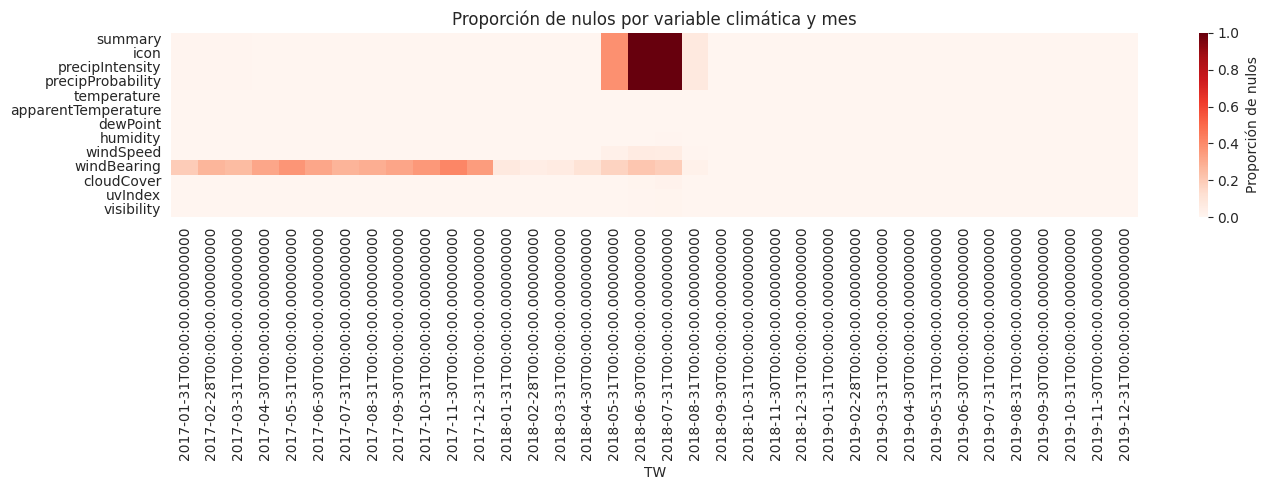

HALLAZGO: Jun-Jul 2018 tienen ausencia total de datos climáticos (proveedor caído).
DECISIÓN: Se excluirán esos dos meses del dataset para evitar imputación masiva artificial.


In [ ]:
# Heatmap de nulos por variable y período mensual — detecta patrones sistemáticos
clima_nulos = (
    clima.set_index('TW')
    .drop(columns=['BARRIO'])
    .isna()
    .resample('ME')
    .mean()
)
plt.figure(figsize=(14, 5))
sns.heatmap(clima_nulos.T, cmap='Reds', cbar_kws={'label': 'Proporción de nulos'})
plt.title('Proporción de nulos por variable climática y mes')
plt.tight_layout()
plt.savefig('figuras/heatmap_nulos.png', dpi=150)
plt.show()
print('HALLAZGO: Jun-Jul 2018 tienen ausencia total de datos climáticos (proveedor caído).')
print('DECISIÓN: Se excluirán esos dos meses del dataset para evitar imputación masiva artificial.')

In [ ]:
# Duplicados y consistencia de llaves de cruce
print('Duplicados (BARRIO,TW) en accidentes:', accidentes.duplicated(subset=['BARRIO','TW']).sum())
print('Duplicados (BARRIO,TW) en clima:',      clima.duplicated(subset=['BARRIO','TW']).sum())

# Radicados duplicados en raw_accidentes
dup_radicados = raw_accidentes['RADICADO'].duplicated().sum()
print(f'Radicados duplicados en raw_accidentes: {dup_radicados}')
raw_accidentes = raw_accidentes.drop_duplicates(subset='RADICADO')

# Normalización de CLASE y GRAVEDAD
for col in ['CLASE', 'GRAVEDAD']:
    if col in raw_accidentes.columns:
        raw_accidentes[col] = raw_accidentes[col].str.strip().str.upper()

# MES_NOMBRE: redundante con Mes numérico y 66% nulos → eliminar
if 'MES_NOMBRE' in raw_accidentes.columns:
    raw_accidentes = raw_accidentes.drop(columns=['MES_NOMBRE'])

print('Calidad raw_accidentes corregida.')

Duplicados (BARRIO,TW) en accidentes: 0
Duplicados (BARRIO,TW) en clima: 0
Radicados duplicados en raw_accidentes: 21
Calidad raw_accidentes corregida.


In [ ]:
# Barrios inconsistentes entre tablas
barrios_clima = set(clima['BARRIO'].unique())
barrios_acc   = set(accidentes['BARRIO'].unique())
sin_match = barrios_acc - barrios_clima
print(f'Barrios en accidentes sin match en clima: {sin_match}')
pct = accidentes['BARRIO'].isin(sin_match).sum() / len(accidentes)
print(f'Representan el {pct:.3%} de registros → se eliminan.')
accidentes = accidentes[~accidentes['BARRIO'].isin(sin_match)].copy()

Barrios en accidentes sin match en clima: {'suburbanoaguasfrias', 'yarumalito', 'elastillero'}
Representan el 0.003% de registros → se eliminan.


In [ ]:
# Imputación de variables climáticas con cascada temporal SIN data leakage
# Lógica: para imputar 2018, solo se usan medianas calculadas con datos de 2017.
# No se usa 2019 porque es el conjunto de test.

VARS_IMPUTAR = ['precipProbability', 'precipIntensity', 'temperature', 'apparentTemperature', 'dewPoint']

# Calcular medianas de referencia solo con 2017
ref2017 = clima[clima['TW'].dt.year == 2017].copy()
ref2017['mes']  = ref2017['TW'].dt.month
ref2017['hora'] = ref2017['TW'].dt.hour

def imputar_cascada(clima, var, ref2017):
    """
    Imputa nulos de una variable climática con cascada de 4 niveles.
    Niveles: barrio+mes+hora → barrio+mes → mes+hora → mes global.
    Solo usa datos de 2017 como referencia (sin leakage hacia 2019).

    Args:
        clima (DataFrame): tabla clima completa con TW como columna.
        var (str): nombre de la variable a imputar.
        ref2017 (DataFrame): subconjunto de clima con solo datos de 2017.
    Returns:
        Series con la variable imputada.
    """
    clima = clima.copy()
    clima['mes']  = clima['TW'].dt.month
    clima['hora'] = clima['TW'].dt.hour

    med_bmh = ref2017.groupby(['BARRIO','mes','hora'])[var].median()
    med_bm  = ref2017.groupby(['BARRIO','mes'])[var].median()
    med_mh  = ref2017.groupby(['mes','hora'])[var].median()
    med_m   = ref2017.groupby('mes')[var].median()

    s = clima[var].copy()
    mask = s.isna()
    s[mask] = clima.loc[mask].apply(
        lambda r: med_bmh.get((r['BARRIO'], r['mes'], r['hora']),
                  med_bm.get((r['BARRIO'], r['mes']),
                  med_mh.get((r['mes'], r['hora']),
                  med_m.get(r['mes'], np.nan)))), axis=1
    )
    return s

for var in VARS_IMPUTAR:
    if var in clima.columns:
        clima[var] = imputar_cascada(clima, var, ref2017)
        print(f'{var}: nulos restantes = {clima[var].isna().sum()}')

# Variables con <0.5% nulos: mediana global
for col in clima.select_dtypes('number').columns:
    n = clima[col].isna().sum()
    if 0 < n / len(clima) < 0.005:
        clima[col] = clima[col].fillna(clima[col].median())

# windBearing: 12.9% nulos, baja relevancia predictiva → eliminar
if 'windBearing' in clima.columns:
    clima = clima.drop(columns=['windBearing'])

# summary: redundante con icon (agrupa las mismas condiciones con más cardinalidad) → eliminar
# icon: se conserva y se codificará posteriormente
if 'summary' in clima.columns:
    clima = clima.drop(columns=['summary'])
clima['icon'] = clima['icon'].fillna('unknown').astype('category')

print('Imputación completada.')

precipProbability: nulos restantes = 10706
precipIntensity: nulos restantes = 10706
temperature: nulos restantes = 12
apparentTemperature: nulos restantes = 12
dewPoint: nulos restantes = 6
Imputación completada.


## 3. Análisis exploratorio (EDA)

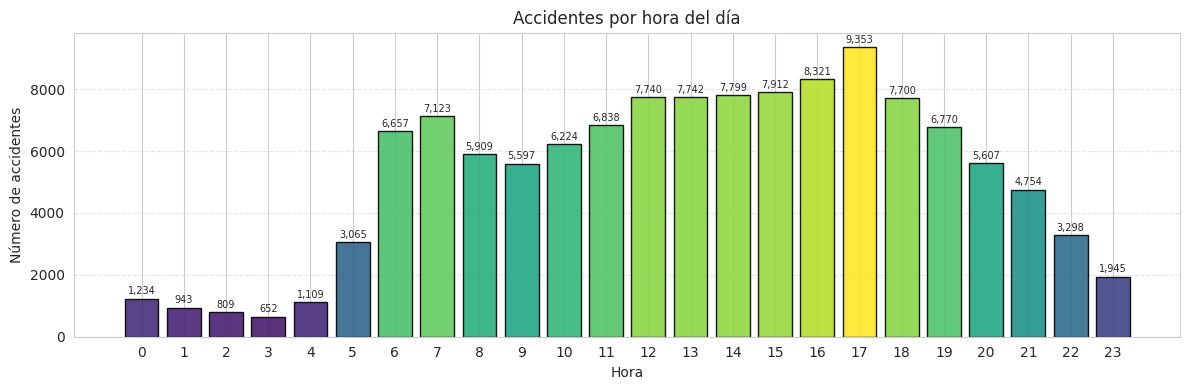

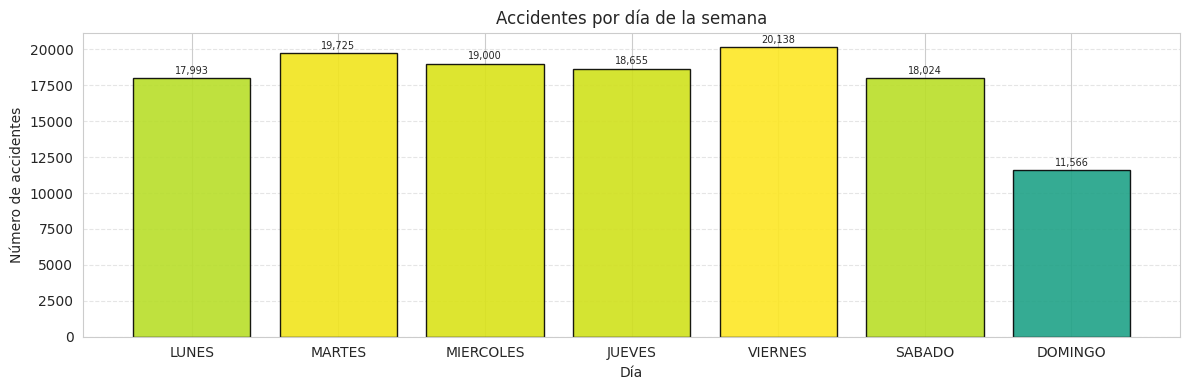

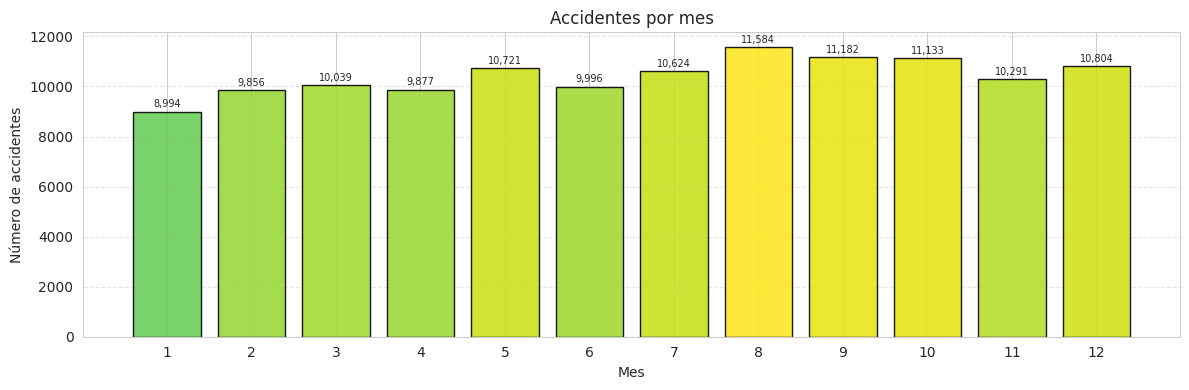

In [ ]:
# 3.1 Distribución temporal
def plot_distribucion(df, columna, titulo, xlabel, orden=None, figsize=(12, 4)):
    """
    Gráfico de barras de frecuencia para una variable categórica o discreta.

    Args:
        df (DataFrame): datos.
        columna (str): variable a graficar.
        titulo (str): título del gráfico.
        xlabel (str): etiqueta del eje X.
        orden (list, optional): orden de categorías.
        figsize (tuple): tamaño de figura.
    """
    counts = df[columna].value_counts()
    if orden:
        counts = counts.reindex(orden, fill_value=0)
    else:
        counts = counts.sort_index()
    colores = plt.cm.viridis(counts.values / counts.values.max())
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(counts.index.astype(str), counts.values, color=colores, edgecolor='black', alpha=0.9)
    ax.set(title=titulo, xlabel=xlabel, ylabel='Número de accidentes')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{int(h):,}', xy=(b.get_x()+b.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'figuras/{columna}_dist.png', dpi=150)
    plt.show()

orden_dias = ['LUNES','MARTES','MIERCOLES','JUEVES','VIERNES','SABADO','DOMINGO']
plot_distribucion(raw_accidentes, 'Hora_num', 'Accidentes por hora del día', 'Hora', list(range(24)))
plot_distribucion(raw_accidentes, 'Dia_sem',  'Accidentes por día de la semana', 'Día', orden_dias)
plot_distribucion(raw_accidentes, 'Mes',      'Accidentes por mes', 'Mes', list(range(1,13)))

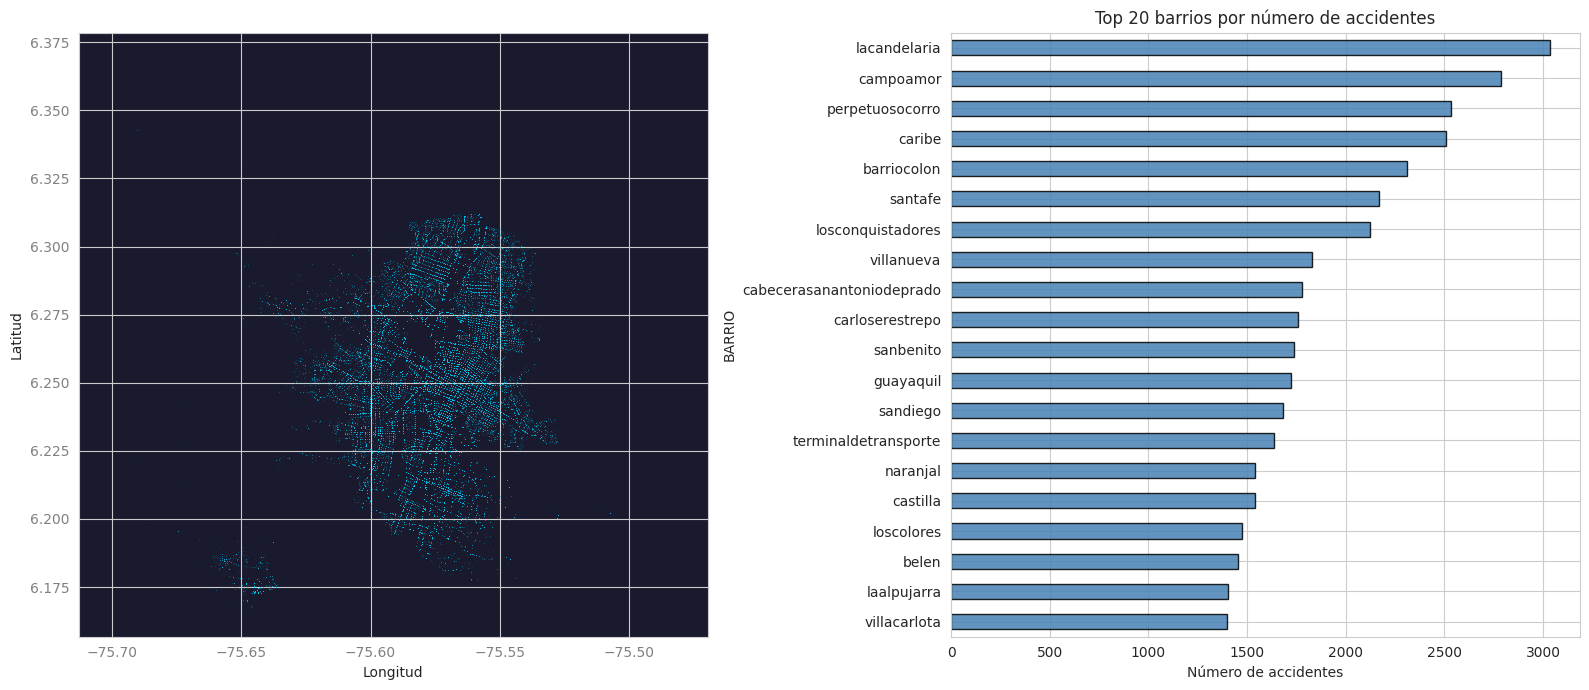

In [ ]:
# 3.2 Distribución espacial — scatter Lat/Lon simula la trama vial de Medellín
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: densidad de puntos (trama vial)
axes[0].set_facecolor('#1a1a2e')
axes[0].scatter(
    raw_accidentes['Lon'], raw_accidentes['Lat'],
    s=0.5, alpha=0.08, color='#00d4ff', linewidths=0
)
axes[0].set_title('Densidad espacial de accidentes (2017-2019)', color='white')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].tick_params(colors='gray')

# Panel derecho: top 20 barrios
top20_barrios = raw_accidentes['BARRIO'].value_counts().head(20)
top20_barrios.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Top 20 barrios por número de accidentes')
axes[1].set_xlabel('Número de accidentes')

plt.tight_layout()
plt.savefig('figuras/distribucion_espacial.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

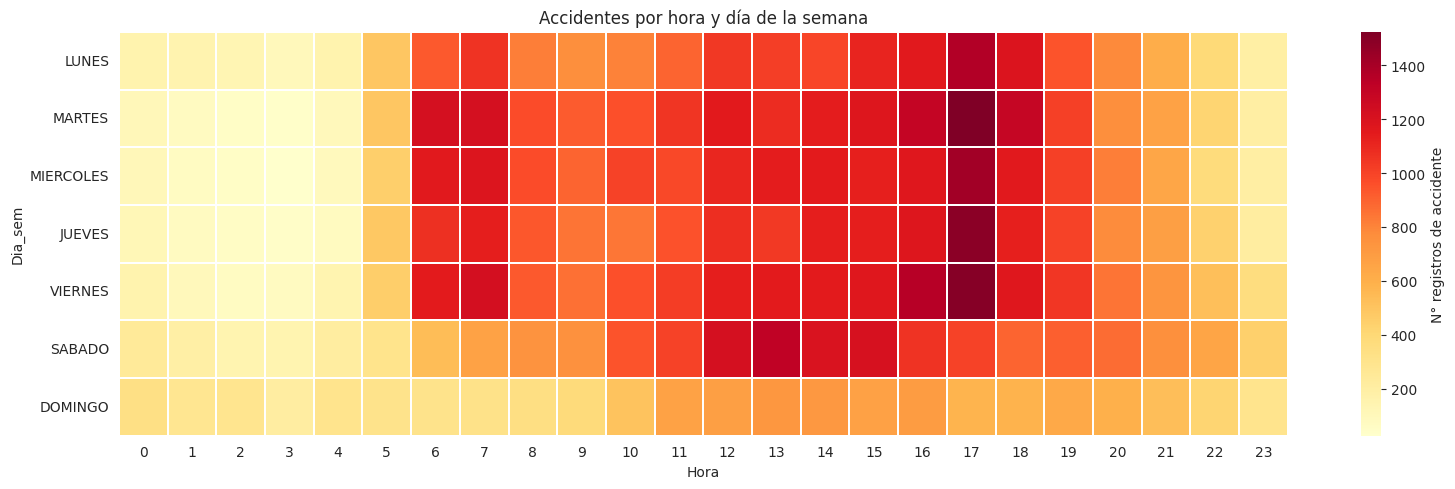

In [ ]:
# 3.3 Heatmap hora × día de la semana
pivot = accidentes.pivot_table(index='Dia_sem', columns='Hora', values='BARRIO', aggfunc='count')
orden = ['LUNES','MARTES','MIERCOLES','JUEVES','VIERNES','SABADO','DOMINGO']
pivot = pivot.reindex([d for d in orden if d in pivot.index])
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'N° registros de accidente'})
ax.set_title('Accidentes por hora y día de la semana')
plt.tight_layout()
plt.savefig('figuras/heatmap_hora_dia.png', dpi=150)
plt.show()

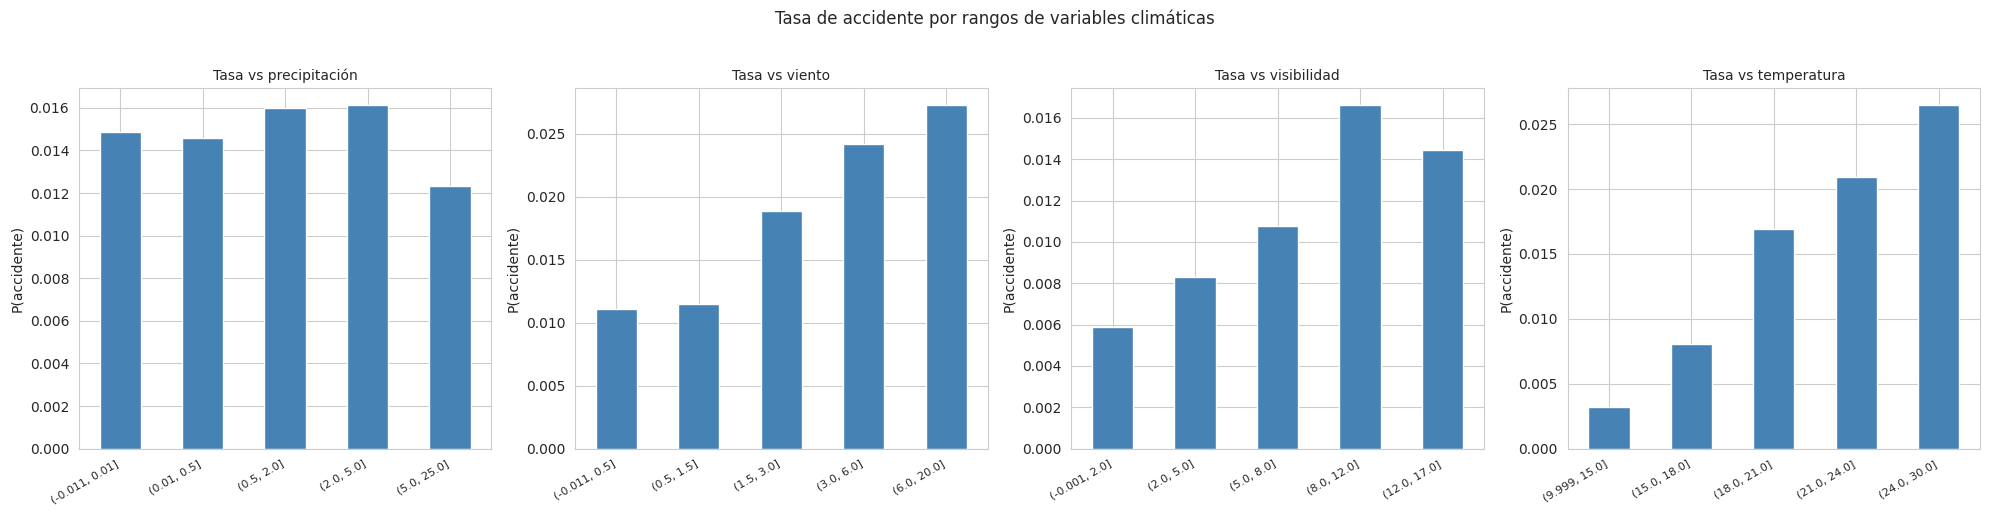

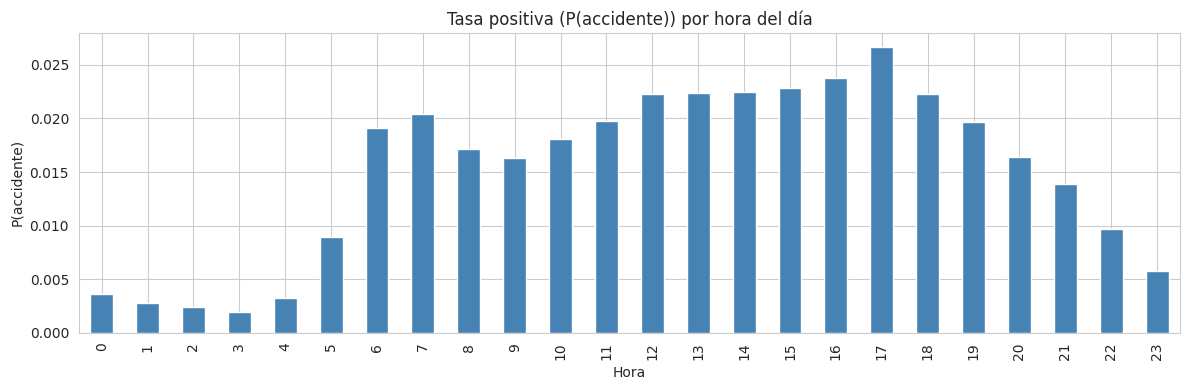

HALLAZGO: lluvia moderada-alta, viento fuerte y visibilidad baja incrementan la tasa positiva.
DECISIÓN: se crearán indicadores binarios para estas condiciones adversas.


34125

In [ ]:
# 3.4 Caracterización climática — tasa positiva por rangos de variables clave
# Este análisis justifica qué variables climáticas entran al modelo

# Construir dataset mínimo para el análisis de tasa positiva
clima_min = clima[['BARRIO','TW']].copy()
idx_acc   = accidentes.set_index(['BARRIO','TW']).index
clima_min['target'] = clima_min.set_index(['BARRIO','TW']).index.isin(idx_acc).astype(int)
clima_full = clima_min.merge(clima, on=['BARRIO','TW'], how='left')

def tasa_por_bins(serie, target, bins, titulo, ax):
    """
    Calcula y grafica la tasa positiva (P(accidente)) por rangos de una variable continua.

    Args:
        serie (Series): variable continua.
        target (Series): variable objetivo binaria.
        bins (list): límites de los rangos.
        titulo (str): título del gráfico.
        ax: eje de matplotlib.
    """
    cat = pd.cut(serie, bins=bins, include_lowest=True)
    target.groupby(cat, observed=False).mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel('P(accidente)')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
tasa_por_bins(clima_full['precipIntensity'], clima_full['target'],
              [-0.01, 0.01, 0.5, 2, 5, 25], 'Tasa vs precipitación', axes[0])
tasa_por_bins(clima_full['windSpeed'],       clima_full['target'],
              [-0.01, 0.5, 1.5, 3, 6, 20],  'Tasa vs viento', axes[1])
tasa_por_bins(clima_full['visibility'],      clima_full['target'],
              [0, 2, 5, 8, 12, 17],          'Tasa vs visibilidad', axes[2])
tasa_por_bins(clima_full['temperature'],     clima_full['target'],
              [10, 15, 18, 21, 24, 30],      'Tasa vs temperatura', axes[3])
plt.suptitle('Tasa de accidente por rangos de variables climáticas', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figuras/tasa_positiva_clima.png', dpi=150)
plt.show()

# Tasa positiva por hora del día
tasa_hora = clima_full.groupby(clima_full['TW'].dt.hour)['target'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
tasa_hora.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Tasa positiva (P(accidente)) por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('P(accidente)')
plt.tight_layout()
plt.savefig('figuras/tasa_positiva_hora.png', dpi=150)
plt.show()

print('HALLAZGO: lluvia moderada-alta, viento fuerte y visibilidad baja incrementan la tasa positiva.')
print('DECISIÓN: se crearán indicadores binarios para estas condiciones adversas.')
del clima_min, clima_full
gc.collect()

## 4. Construcción del dataset supervisado

In [ ]:
# 4.1 Unión de tablas — left join desde clima (universo completo de combinaciones barrio×hora)
# Justificación: clima tiene TODAS las combinaciones (barrio, hora); accidentes solo las positivas.
# El target = 1 cuando existe match, 0 en caso contrario.

df = clima.merge(
    accidentes[['BARRIO','TW']].assign(target=1),
    on=['BARRIO','TW'], how='left'
)
df['target'] = df['target'].fillna(0).astype('int8')

print(f'Shape dataset unido: {df.shape}')
print(f'Proporción positivos: {df["target"].mean():.4%} — desbalance 1:{int(1/df["target"].mean())}')

del accidentes, clima
gc.collect()
monitor_memoria()

Shape dataset unido: (7991780, 14)
Proporción positivos: 1.5075% — desbalance 1:66
RAM total: 13.6 GB | Usada: 10.1 GB | Libre: 3.2 GB (76.4%)


In [ ]:
# 4.2 Exclusión de jun-jul 2018 (ausencia total del proveedor climático)
# Imputar 2 meses completos de datos faltantes introduciría ruido artificial.
mask_excluir = (df['TW'].dt.year == 2018) & (df['TW'].dt.month.isin([6, 7]))
print(f'Registros excluidos (jun-jul 2018): {mask_excluir.sum():,}')
df = df[~mask_excluir].copy()
print(f'Shape tras exclusión: {df.shape}')

Registros excluidos (jun-jul 2018): 440,725
Shape tras exclusión: (7551055, 14)


In [ ]:
# 4.3 Partición temporal — PRIMERO partir, LUEGO muestrear
# Tres bloques: train | validation | test
# Train:      2017-01 a 2018-09 → aprender patrones
# Validation: 2018-10 a 2018-12 → seleccionar modelo y umbral
# Test:       2019 completo      → evaluación final una sola vez

FECHA_VAL  = '2018-10-01'
FECHA_TEST = '2019-01-01'

mask_train = df['TW'] <  FECHA_VAL
mask_val   = (df['TW'] >= FECHA_VAL) & (df['TW'] < FECHA_TEST)
mask_test  = df['TW'] >= FECHA_TEST

print(f'Train: {mask_train.sum():,} filas | tasa positiva: {df.loc[mask_train,"target"].mean():.4%}')
print(f'Val:   {mask_val.sum():,} filas | tasa positiva: {df.loc[mask_val,"target"].mean():.4%}')
print(f'Test:  {mask_test.sum():,} filas | tasa positiva: {df.loc[mask_test,"target"].mean():.4%}')

Train: 4,267,135 filas | tasa positiva: 1.4889%
Val:   673,440 filas | tasa positiva: 1.4545%
Test:  2,610,480 filas | tasa positiva: 1.5656%


In [ ]:
# 4.4 Baseline ingenuo — por qué accuracy no sirve
from sklearn.metrics import confusion_matrix, accuracy_score

y_test_baseline = df.loc[mask_test, 'target']
y_pred_baseline = np.zeros(len(y_test_baseline), dtype=int)

cm = confusion_matrix(y_test_baseline, y_pred_baseline)
tn, fp, fn, tp = cm.ravel()

accuracy_baseline = accuracy_score(y_test_baseline, y_pred_baseline)
tasa_positiva     = y_test_baseline.mean()

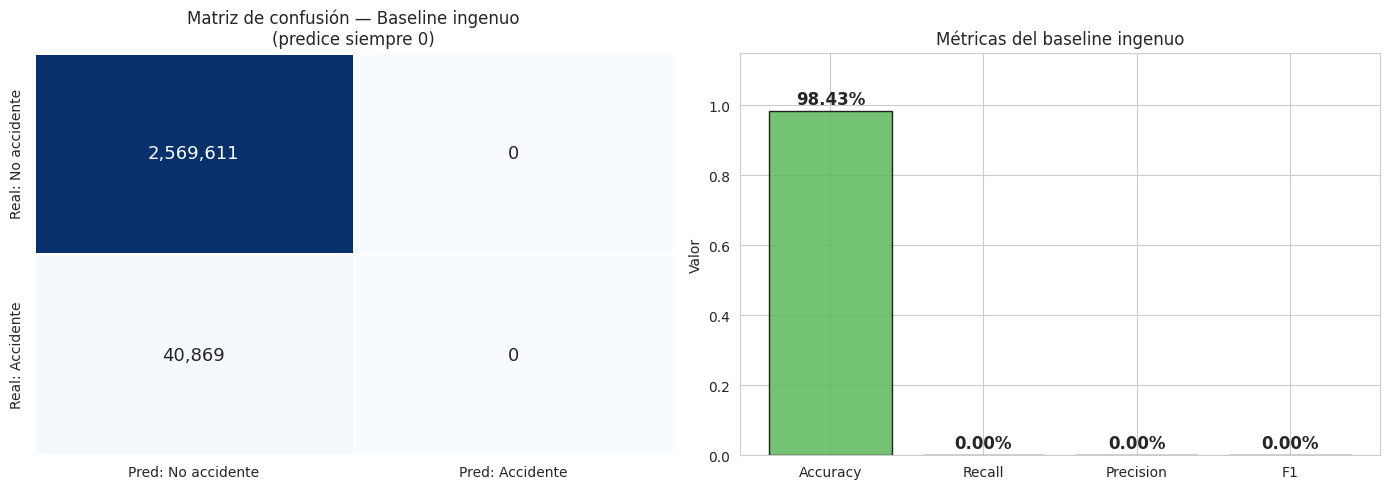

Desbalance en test:        1 accidente por cada 63 horas
Accuracy baseline:         98.4344%
Accidentes reales (FN):    40,869 — recall = 0%
Conclusión: accuracy alta no significa modelo útil.


In [ ]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — matriz de confusión
cm_data = np.array([[tn, fp], [fn, tp]])
sns.heatmap(
    cm_data, annot=True, fmt=',', cmap='Blues',
    xticklabels=['Pred: No accidente', 'Pred: Accidente'],
    yticklabels=['Real: No accidente', 'Real: Accidente'],
    ax=axes[0], cbar=False, linewidths=1,
    annot_kws={'size': 13}
)
axes[0].set_title('Matriz de confusión — Baseline ingenuo\n(predice siempre 0)', fontsize=12)

# Panel derecho — métricas
metricas = ['Accuracy', 'Recall', 'Precision', 'F1']
valores  = [accuracy_baseline, 0.0, 0.0, 0.0]
colores  = ['#5cb85c', '#d9534f', '#d9534f', '#d9534f']
bars = axes[1].bar(metricas, valores, color=colores, edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Métricas del baseline ingenuo', fontsize=12)
axes[1].set_ylabel('Valor')
for bar, val in zip(bars, valores):
    axes[1].annotate(
        f'{val:.2%}',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('figuras/baseline_ingenuo.png', dpi=150)
plt.show()

print(f'Desbalance en test:        1 accidente por cada {int(1/tasa_positiva)} horas')
print(f'Accuracy baseline:         {accuracy_baseline:.4%}')
print(f'Accidentes reales (FN):    {fn:,} — recall = 0%')
print(f'Conclusión: accuracy alta no significa modelo útil.')

### ¿Por qué accuracy no sirve aquí?

El dataset de test tiene proporción real de **1 accidente por cada ~62 horas sin accidente**.
Un modelo que predice *siempre* "no hay accidente" alcanza una accuracy del **98.4%** sin
haber aprendido absolutamente nada — simplemente refleja que la clase negativa domina.

La matriz de confusión lo evidencia: todos los accidentes reales caen en **FN** (falsos negativos),
es decir, el modelo los ignora por completo. Desde el punto de vista operacional de la
Secretaría de Movilidad, este modelo es completamente inútil.

**Métricas adecuadas para este problema:**
- **ROC-AUC y PR-AUC**: independientes del umbral, miden la capacidad discriminativa real
- **Recall**: fracción de accidentes reales detectados — crítico porque FN > FP en costo
- **Precision y F1**: para entender el trade-off con las falsas alarmas

## 5. Ingeniería de características (sin data leakage)

In [ ]:
# 5.1 Variables temporales y cíclicas
def agregar_features_temporales(df, anios_festivos=range(2017, 2020)):
    """
    Agrega variables derivadas de TW: componentes temporales, flags y codificación cíclica.

    Args:
        df (DataFrame): dataset con columna TW.
        anios_festivos (range): años para el calendario de festivos Colombia.
    Returns:
        DataFrame con nuevas columnas.
    """
    festivos_co = pd.to_datetime(list(holidays.country_holidays('CO', years=anios_festivos)))

    df['Hora']       = df['TW'].dt.hour.astype('int8')
    df['Dia']        = df['TW'].dt.day.astype('int8')
    df['Mes']        = df['TW'].dt.month.astype('int8')
    df['dia_sem']    = df['TW'].dt.dayofweek.astype('int8')
    df['es_finde']   = (df['dia_sem'] >= 5).astype('int8')
    df['es_festivo'] = df['TW'].dt.normalize().isin(festivos_co).astype('int8')
    df['hora_pico']  = df['Hora'].isin([7,8,9,17,18,19]).astype('int8')  # pico EDA

    # Codificación cíclica: permite que 23h y 0h sean vecinas
    df['hora_sin']    = np.sin(2*np.pi*df['Hora']/24).astype('float32')
    df['hora_cos']    = np.cos(2*np.pi*df['Hora']/24).astype('float32')
    df['dia_sin']     = np.sin(2*np.pi*df['dia_sem']/7).astype('float32')
    df['dia_cos']     = np.cos(2*np.pi*df['dia_sem']/7).astype('float32')
    df['mes_sin']     = np.sin(2*np.pi*df['Mes']/12).astype('float32')
    df['mes_cos']     = np.cos(2*np.pi*df['Mes']/12).astype('float32')
    doy = df['TW'].dt.dayofyear
    df['doy_sin']     = np.sin(2*np.pi*doy/365).astype('float32')
    df['doy_cos']     = np.cos(2*np.pi*doy/365).astype('float32')
    return df

df = agregar_features_temporales(df)
print('Variables temporales y cíclicas creadas.')

Variables temporales y cíclicas creadas.


In [ ]:
# 5.2 Indicadores climáticos binarios — motivados por EDA (sección 3.4)
def agregar_indicadores_climaticos(df):
    """
    Crea indicadores binarios de condiciones adversas identificadas en el EDA.
    Lluvia moderada, viento fuerte y visibilidad baja incrementan P(accidente).

    Args:
        df (DataFrame): dataset con variables climáticas.
    Returns:
        DataFrame con indicadores binarios adicionales.
    """
    df['lluvia_fuerte']   = (df['precipIntensity'] > 5).astype('int8')
    df['viento_fuerte']   = (df['windSpeed'] > 3).astype('int8')
    df['visibilidad_baja']= (df['visibility'] < 5).astype('int8')
    return df

df = agregar_indicadores_climaticos(df)
print('Indicadores climáticos binarios creados.')

Indicadores climáticos binarios creados.


In [ ]:
# 5.3 COMUNA — agrupación geográfica de segundo nivel
mapa_comuna = (
    raw_accidentes[['BARRIO','COMUNA']]
    .drop_duplicates(subset='BARRIO')
    .set_index('BARRIO')['COMUNA']
    .to_dict()
)
df['COMUNA'] = df['BARRIO'].map(mapa_comuna).astype('category')
print(f'COMUNA: {df["COMUNA"].nunique()} comunas distintas.')

COMUNA: 26 comunas distintas.


In [ ]:
# 5.4 Historial de accidentes por barrio — ventana expansiva SIN leakage
# Versión sin acumulación de frames — escribe directo sobre df

raw_min = raw_accidentes[['TW', 'BARRIO', 'Hora_num']].copy()
raw_min['anio'] = raw_min['TW'].dt.year
df['anio'] = df['TW'].dt.year

hist_b_anio  = raw_min.groupby(['BARRIO','anio']).size().rename('cnt').reset_index()
hist_bh_anio = raw_min.groupby(['BARRIO','Hora_num','anio']).size().rename('cnt').reset_index()

del raw_min
gc.collect()
monitor_memoria()

# Inicializar columnas con ceros
df['hist_accidentes_barrio']      = np.float32(0)
df['hist_accidentes_barrio_hora'] = np.float32(0)

# Escribir directo por año sin acumular copias
for anio in sorted(df['anio'].unique()):
    mask_anio = df['anio'] == anio

    acum_b = hist_b_anio[hist_b_anio['anio'] < anio].groupby('BARRIO')['cnt'].sum()
    df.loc[mask_anio, 'hist_accidentes_barrio'] = (
        df.loc[mask_anio, 'BARRIO'].map(acum_b).fillna(0).astype('float32').values
    )

    acum_bh = hist_bh_anio[hist_bh_anio['anio'] < anio].groupby(['BARRIO','Hora_num'])['cnt'].sum()
    idx_multi = pd.MultiIndex.from_arrays([
        df.loc[mask_anio, 'BARRIO'],
        df.loc[mask_anio, 'Hora']
    ])
    df.loc[mask_anio, 'hist_accidentes_barrio_hora'] = (
        idx_multi.map(acum_bh).fillna(0).astype('float32').values
    )

df = df.drop(columns=['anio'])

del hist_b_anio, hist_bh_anio
gc.collect()
monitor_memoria()

print('Columnas históricas:', [c for c in df.columns if 'hist' in c])
print(df[['hist_accidentes_barrio','hist_accidentes_barrio_hora']].describe())

RAM total: 13.6 GB | Usada: 10.4 GB | Libre: 2.9 GB (78.4%)
RAM total: 13.6 GB | Usada: 10.9 GB | Libre: 2.4 GB (82.3%)
Columnas históricas: ['hist_accidentes_barrio', 'hist_accidentes_barrio_hora']
       hist_accidentes_barrio  hist_accidentes_barrio_hora
count            7.551055e+06                 7.551055e+06
mean             1.368313e+02                 5.701405e+00
std              2.434500e+02                 1.246068e+01
min              0.000000e+00                 0.000000e+00
25%              0.000000e+00                 0.000000e+00
50%              3.500000e+01                 1.000000e+00
75%              1.760000e+02                 6.000000e+00
max              1.931000e+03                 1.720000e+02


In [ ]:
# 5.5 Rolling 7 días previos por barrio — tendencia reciente sin leakage
# Se calcula desde raw_accidentes directamente con agregación eficiente

# Agrupar por barrio y día — sin resample que expande en RAM
raw_daily = (
    raw_accidentes[['TW', 'BARRIO']]
    .copy()
)
raw_daily['fecha'] = raw_daily['TW'].dt.normalize()
raw_daily = raw_daily.groupby(['BARRIO', 'fecha']).size().rename('cnt').reset_index()

# Rolling 7 días con shift(1) por barrio
raw_daily = raw_daily.sort_values(['BARRIO', 'fecha'])
raw_daily['rolling_7d_barrio'] = (
    raw_daily.groupby('BARRIO')['cnt']
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
).astype('float32')

# Merge al df principal — TW del df tiene hora, fecha es solo el día
df['fecha'] = df['TW'].dt.normalize()
df = df.merge(
    raw_daily[['BARRIO', 'fecha', 'rolling_7d_barrio']],
    on=['BARRIO', 'fecha'], how='left'
)
df['rolling_7d_barrio'] = df['rolling_7d_barrio'].fillna(0).astype('float32')
df = df.drop(columns=['fecha'])

del raw_accidentes, raw_daily, mapa_comuna
gc.collect()
monitor_memoria()
print('Rolling 7 días calculado.')
print(df['rolling_7d_barrio'].describe())

RAM total: 13.6 GB | Usada: 10.6 GB | Libre: 2.7 GB (80.3%)
Rolling 7 días calculado.
count    7.551055e+06
mean     3.752508e-01
std      7.265040e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.857143e+00
Name: rolling_7d_barrio, dtype: float64


In [ ]:
# Recalcular máscaras temporales después del histórico expansivo
mask_train = df['TW'] <  FECHA_VAL
mask_val   = (df['TW'] >= FECHA_VAL) & (df['TW'] < FECHA_TEST)
mask_test  = df['TW'] >= FECHA_TEST

# Ahora sí el frequency encoding
freq_barrio = (
    df.loc[mask_train, 'BARRIO']
    .value_counts(normalize=True)
    .rename('barrio_freq')
)
df['barrio_freq'] = df['BARRIO'].map(freq_barrio).fillna(0).astype('float32')

In [ ]:
# 5.6 Frequency encoding de BARRIO — calculado solo sobre train para evitar leakage
# icon y COMUNA se codificarán con TargetEncoder dentro del pipeline (sección 7)

freq_barrio = (
    df.loc[mask_train, 'BARRIO']
    .value_counts(normalize=True)
    .rename('barrio_freq')
)
df['barrio_freq'] = df['BARRIO'].map(freq_barrio).fillna(0).astype('float32')
print(f'Frequency encoding de BARRIO calculado sobre train ({mask_train.sum():,} filas).')
print(f'Barrios en test sin match: {df.loc[mask_test,"barrio_freq"].eq(0).sum():,} → reciben frecuencia 0.')

Frequency encoding de BARRIO calculado sobre train (4,267,135 filas).
Barrios en test sin match: 26,280 → reciben frecuencia 0.


In [ ]:
# 5.7 Resumen final de features
cols_excluir = ['TW', 'target', 'BARRIO', 'COMUNA', 'icon']
FEATURE_COLS = [c for c in df.columns if c not in cols_excluir]
print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

# Guardar checkpoint
df.to_parquet('checkpoints/df_features.parquet', index=False)
print('Checkpoint guardado.')

Total features: 32
['precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 'cloudCover', 'uvIndex', 'visibility', 'Hora', 'Dia', 'Mes', 'dia_sem', 'es_finde', 'es_festivo', 'hora_pico', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'doy_sin', 'doy_cos', 'lluvia_fuerte', 'viento_fuerte', 'visibilidad_baja', 'hist_accidentes_barrio', 'hist_accidentes_barrio_hora', 'rolling_7d_barrio', 'barrio_freq']
Checkpoint guardado.


## 6. Manejo del desbalance

In [ ]:
# Separar conjuntos — NUNCA aplicar balanceo a val o test
X_train_full = df.loc[mask_train, FEATURE_COLS]
y_train_full = df.loc[mask_train, 'target']
X_val        = df.loc[mask_val,   FEATURE_COLS]
y_val        = df.loc[mask_val,   'target']
X_test       = df.loc[mask_test,  FEATURE_COLS]
y_test       = df.loc[mask_test,  'target']

print(f'Train: {X_train_full.shape} | positivos: {y_train_full.sum():,} ({y_train_full.mean():.2%})')
print(f'Val:   {X_val.shape}        | positivos: {y_val.sum():,} ({y_val.mean():.2%})')
print(f'Test:  {X_test.shape}       | positivos: {y_test.sum():,} ({y_test.mean():.2%})')

Train: (4267135, 32) | positivos: 63,534 (1.49%)
Val:   (673440, 32)        | positivos: 9,795 (1.45%)
Test:  (2610480, 32)       | positivos: 40,869 (1.57%)


In [ ]:
# Comparación de 3 estrategias de balanceo con Regresión Logística como modelo fijo
# Usar LR fijo aísla el efecto del balanceo, descartando variación por capacidad del modelo.

from sklearn.utils import resample as sk_resample

def undersample_train(X, y, ratio=10, random_state=42):
    """
    Undersampling de negativos en train manteniendo todos los positivos.
    """
    pos_idx = y[y == 1].index
    neg_idx = y[y == 0].index
    neg_sample = np.random.RandomState(random_state).choice(
        neg_idx, size=len(pos_idx)*ratio, replace=False
    )
    idx = np.concatenate([pos_idx, neg_sample])
    return X.loc[idx], y.loc[idx]

X_us, y_us = undersample_train(X_train_full, y_train_full, UNDERSAMPLE_RATIO)
print(f'Train undersampled: {X_us.shape} | positivos: {y_us.mean():.2%}')

# Liberar X_train_full — ya no lo necesitamos
del X_train_full
gc.collect()
monitor_memoria()

# SMOTE solo sobre una muestra pequeña (30% de X_us) para no matar RAM
X_us_muestra = X_us.sample(frac=0.3, random_state=RANDOM_STATE)
y_us_muestra = y_us.loc[X_us_muestra.index]
smote = SMOTE(random_state=RANDOM_STATE)
X_sm, y_sm = smote.fit_resample(X_us_muestra, y_us_muestra)
print(f'Train SMOTE (muestra 30%): {X_sm.shape} | positivos: {y_sm.mean():.2%}')
del X_us_muestra, y_us_muestra
gc.collect()

# Comparación — todo sobre conjuntos manejables, scaler por estrategia
def eval_balanceo(nombre, X_tr, y_tr, class_weight=None):
    """
    Entrena Logística sobre X_tr y evalúa en validación.
    Cada llamada crea su propio scaler para evitar contaminación.
    """
    sc = StandardScaler()
    lr = LogisticRegression(
        max_iter=500, class_weight=class_weight,
        random_state=RANDOM_STATE, n_jobs=-1, solver='saga'
    )
    lr.fit(sc.fit_transform(X_tr), y_tr)
    proba = lr.predict_proba(sc.transform(X_val))[:,1]
    pred  = (proba >= 0.5).astype(int)
    return {
        'Estrategia': nombre,
        'ROC-AUC':   round(roc_auc_score(y_val, proba), 4),
        'PR-AUC':    round(average_precision_score(y_val, proba), 4),
        'Recall':    round(recall_score(y_val, pred), 4),
        'Precision': round(precision_score(y_val, pred, zero_division=0), 4),
        'F1':        round(f1_score(y_val, pred), 4),
    }

resultados_balanceo = pd.DataFrame([
    eval_balanceo('Baseline (sin balanceo)',  X_us, y_us),
    eval_balanceo('class_weight=balanced',    X_us, y_us, class_weight='balanced'),
    eval_balanceo('Undersampling 1:10',       X_us, y_us),
    eval_balanceo('SMOTE (muestra 30%)',      X_sm, y_sm),
])

del X_sm, y_sm
gc.collect()

print(resultados_balanceo.to_string(index=False))
print('\nCONCLUSIÓN: diferencias mínimas — el cuello de botella es la capacidad del modelo.')
print('DECISIÓN: se usará undersampling 1:10 por eficiencia computacional.')

Train undersampled: (698874, 32) | positivos: 9.09%
RAM total: 13.6 GB | Usada: 11.4 GB | Libre: 2.0 GB (85.6%)
Train SMOTE (muestra 30%): (381268, 32) | positivos: 50.00%
             Estrategia  ROC-AUC  PR-AUC  Recall  Precision     F1
Baseline (sin balanceo)   0.9129  0.1024  0.2016     0.1274 0.1562
  class_weight=balanced   0.9166  0.0974  0.9433     0.0704 0.1310
     Undersampling 1:10   0.9129  0.1024  0.2016     0.1274 0.1562
    SMOTE (muestra 30%)   0.9154  0.0978  0.8362     0.0745 0.1367

CONCLUSIÓN: diferencias mínimas — el cuello de botella es la capacidad del modelo.
DECISIÓN: se usará undersampling 1:10 por eficiencia computacional.


## 7. Modelado comparativo

In [ ]:
# Pipeline sklearn: preprocesamiento + modelo en un solo objeto
# Garantiza que imputer y scaler se ajustan solo sobre el train de cada fold

# Detectar GPU disponible — portable entre entornos
import subprocess
try:
    subprocess.check_output('nvidia-smi')
    GPU_DISPONIBLE = True
    print('GPU detectada — entrenamiento acelerado')
except:
    GPU_DISPONIBLE = False
    print('Sin GPU — entrenamiento en CPU')

lgbm_device = 'gpu'  if GPU_DISPONIBLE else 'cpu'
xgb_device  = 'cuda' if GPU_DISPONIBLE else 'cpu'

# Columnas reales disponibles en X_us — evita KeyError si icon/COMUNA no están
cat_cols = [c for c in ['icon', 'COMUNA'] if c in X_us.columns]
num_cols = [c for c in X_us.columns   if c not in cat_cols]

print(f'num_cols: {len(num_cols)} | cat_cols: {cat_cols}')

# Preprocesador para modelos lineales (con escalado)
prep_lineal = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), num_cols),
], remainder='drop')

# Preprocesador para modelos de árbol (sin escalado)
prep_arbol = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
], remainder='drop')

MODELOS = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
        prep_lineal
    ),
    'RandomForest': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1),
        prep_arbol
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      scale_pos_weight=UNDERSAMPLE_RATIO,
                      device=xgb_device,
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        prep_arbol
    ),
    'LightGBM': (
        LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                       class_weight='balanced',
                       device=lgbm_device,
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        prep_arbol
    ),
}
print('Definición de modelos lista.')

GPU detectada — entrenamiento acelerado
num_cols: 32 | cat_cols: []
Definición de modelos lista.


In [ ]:
# Redefinir preprocesadores basándose en columnas reales de X_us
cat_cols = [c for c in ['icon', 'COMUNA'] if c in X_us.columns]
num_cols = [c for c in X_us.columns if c not in cat_cols]

print(f'num_cols: {len(num_cols)} | cat_cols: {cat_cols}')

prep_lineal = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), num_cols),
], remainder='drop')

prep_arbol = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
], remainder='drop')

MODELOS = {
    'LogisticRegression': (
        LogisticRegression(max_iter=500, class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1, solver='saga'),
        prep_lineal
    ),
    'RandomForest': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1),
        prep_arbol
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      scale_pos_weight=UNDERSAMPLE_RATIO,
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        prep_arbol
    ),
    'LightGBM': (
        LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                       class_weight='balanced',
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        prep_arbol
    ),
}

num_cols: 32 | cat_cols: []


In [ ]:
# Ordenar train por fecha para TimeSeriesSplit
orden_ts = df.loc[mask_train, 'TW'].sort_values().index
X_us_ord = X_us.loc[X_us.index.isin(orden_ts)].sort_index()
y_us_ord = y_us.loc[X_us_ord.index]

# Muestra 20% para tuning
X_us_tune = X_us_ord.sample(frac=0.20, random_state=RANDOM_STATE)
y_us_tune = y_us_ord.loc[X_us_tune.index]

tscv = TimeSeriesSplit(n_splits=3)

PARAM_DIST = {
    'LogisticRegression': {'clf__C': uniform(0.01, 10)},
    'RandomForest':       {'clf__n_estimators': randint(100, 200),
                           'clf__max_depth': randint(5, 12)},
    'XGBoost':            {'clf__n_estimators': randint(100, 250),
                           'clf__learning_rate': uniform(0.05, 0.1),
                           'clf__max_depth': randint(3, 6)},
    'LightGBM':           {'clf__n_estimators': randint(100, 250),
                           'clf__learning_rate': uniform(0.05, 0.1),
                           'clf__num_leaves': randint(31, 63),
                           'clf__min_child_samples': randint(20, 100)},
}

mejores_pipes = {}
resultados_cv = []

for nombre, (modelo, prep) in MODELOS.items():
    ruta = f'modelos/{nombre}.joblib'

    # Skip si ya está guardado en esta sesión
    if os.path.exists(ruta):
        print(f'\n✓ {nombre} ya existe — cargando desde disco')
        mejores_pipes[nombre] = joblib.load(ruta)
        proba_val = mejores_pipes[nombre].predict_proba(X_val)[:,1]
        resultados_cv.append({
            'Modelo': nombre,
            'CV_PR-AUC (media)': None,
            'Val_ROC-AUC': roc_auc_score(y_val, proba_val),
            'Val_PR-AUC':  average_precision_score(y_val, proba_val),
            'Val_Recall':  recall_score(y_val, (proba_val>=0.5).astype(int)),
        })
        continue

    print(f'\nTuning {nombre}...')
    pipe = Pipeline([('prep', clone(prep)), ('clf', clone(modelo))])
    n_iter = 5 if nombre == 'LightGBM' else 3

    search = RandomizedSearchCV(
        pipe, PARAM_DIST[nombre], n_iter=n_iter,
        cv=tscv, scoring='average_precision',
        n_jobs=1, random_state=RANDOM_STATE, verbose=1
    )
    search.fit(X_us_tune, y_us_tune)
    print(f'Mejores params: {search.best_params_}')

    # Reentrenar sobre X_us completo con mejores hiperparámetros
    mejor_pipe = clone(search.best_estimator_)
    mejor_pipe.fit(X_us_ord, y_us_ord)
    mejores_pipes[nombre] = mejor_pipe

    proba_val = mejor_pipe.predict_proba(X_val)[:,1]
    resultados_cv.append({
        'Modelo': nombre,
        'CV_PR-AUC (media)': search.best_score_,
        'Val_ROC-AUC': roc_auc_score(y_val, proba_val),
        'Val_PR-AUC':  average_precision_score(y_val, proba_val),
        'Val_Recall':  recall_score(y_val, (proba_val>=0.5).astype(int)),
    })

    joblib.dump(mejor_pipe, ruta)
    print(f'✓ {nombre} guardado en modelos/{nombre}.joblib')
    # NOTA: si el runtime se reinicia estos archivos se pierden.
    # Para persistir entre sesiones, copiar manualmente a Drive.

    del search
    gc.collect()
    monitor_memoria()

tabla_cv = pd.DataFrame(resultados_cv).set_index('Modelo')
print('\n--- Tabla comparativa en validación ---')
print(tabla_cv.round(4))


Tuning LogisticRegression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores params: {'clf__C': np.float64(3.7554011884736247)}
✓ LogisticRegression guardado en modelos/LogisticRegression.joblib
RAM total: 13.6 GB | Usada: 11.3 GB | Libre: 2.0 GB (85.3%)

Tuning RandomForest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores params: {'clf__max_depth': 9, 'clf__n_estimators': 114}
✓ RandomForest guardado en modelos/RandomForest.joblib
RAM total: 13.6 GB | Usada: 11.4 GB | Libre: 1.9 GB (86.0%)

Tuning XGBoost...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores params: {'clf__learning_rate': np.float64(0.08745401188473625), 'clf__max_depth': 3, 'clf__n_estimators': 114}
✓ XGBoost guardado en modelos/XGBoost.joblib
RAM total: 13.6 GB | Usada: 11.5 GB | Libre: 1.8 GB (86.9%)

Tuning LightGBM...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores params: {'clf__learning_rate': np.float64(0.05564115790271003), 'clf__min

## 8. Selección del modelo final y análisis de importancia

In [ ]:
import pandas as pd
df_check = pd.read_parquet('checkpoints/df_features.parquet')
print(df_check.columns.tolist())
print(df_check.shape)

['TW', 'BARRIO', 'icon', 'precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 'cloudCover', 'uvIndex', 'visibility', 'target', 'Hora', 'Dia', 'Mes', 'dia_sem', 'es_finde', 'es_festivo', 'hora_pico', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'doy_sin', 'doy_cos', 'lluvia_fuerte', 'viento_fuerte', 'visibilidad_baja', 'COMUNA', 'hist_accidentes_barrio', 'hist_accidentes_barrio_hora', 'rolling_7d_barrio', 'barrio_freq']
(7551055, 37)


Candidato inicial: LightGBM


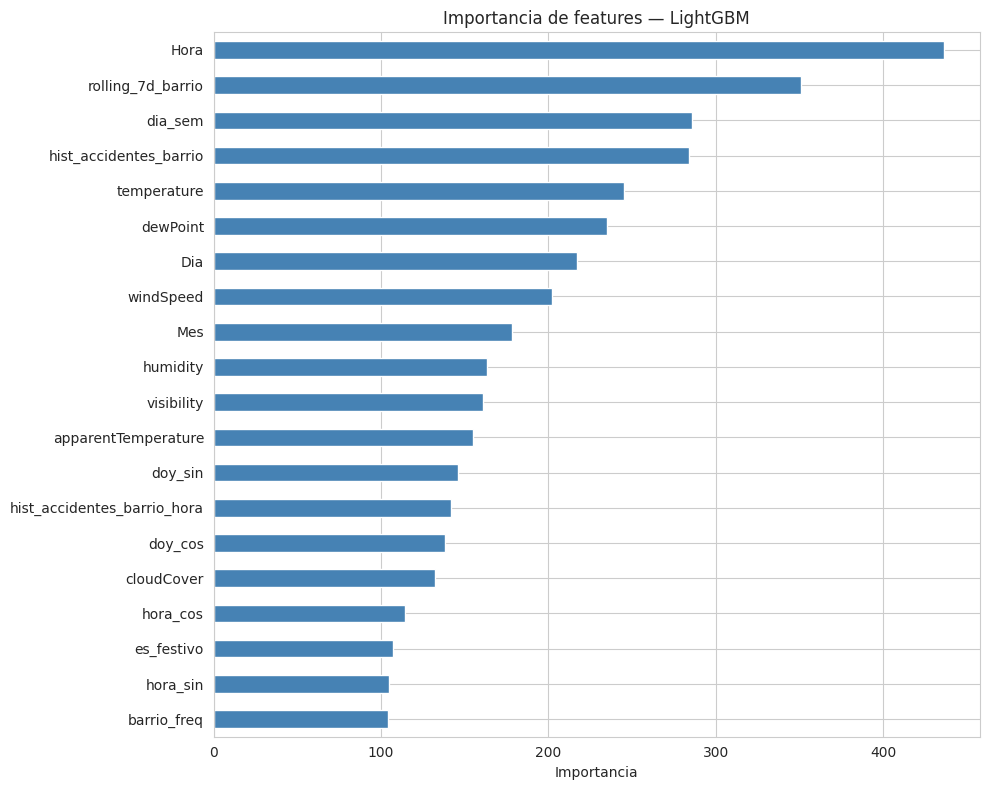


Feature más importante: Hora (10.3% del total)


In [ ]:
# El modelo con mejor Val_ROC-AUC y Val_Recall es candidato final
mejor_nombre = tabla_cv['Val_ROC-AUC'].idxmax()
print(f'Candidato inicial: {mejor_nombre}')

# Análisis de importancia de features (LightGBM)
lgbm_pipe = mejores_pipes['LightGBM']
importancias = lgbm_pipe.named_steps['clf'].feature_importances_
feature_names_out = num_cols + cat_cols  # orden del ColumnTransformer
imp_df = pd.Series(importancias, index=feature_names_out).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_df.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de features — LightGBM')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('figuras/importancia_features.png', dpi=150)
plt.show()

# Revisar si alguna variable domina con >30% del total
pct_top = importancias.max() / importancias.sum()
top_feature = imp_df.index[0]
print(f'\nFeature más importante: {top_feature} ({pct_top:.1%} del total)')
if pct_top > 0.30:
    print('⚠ Dominancia detectada — se evaluará reentrenar sin esta feature.')

In [ ]:
# Si hay dominancia, comparar v1 (con la feature) vs v2 (sin ella)
# Esto mejora la granularidad temporal del mapa de riesgo

if pct_top > 0.30:
    print(f'Reentrenando LightGBM sin {top_feature}...')
    feat_v2 = [c for c in FEATURE_COLS if c != top_feature]
    num_v2  = [c for c in feat_v2 if c not in cat_cols]

    prep_v2 = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_v2),
        ('cat', SimpleImputer(strategy='most_frequent'), cat_cols)
    ], remainder='drop')

    lgbm_v2_base = LGBMClassifier(
        **{k.replace('clf__',''):v
           for k,v in mejores_pipes['LightGBM'].named_steps['clf'].get_params().items()}
    )
    pipe_v2 = Pipeline([('prep', prep_v2), ('clf', lgbm_v2_base)])
    pipe_v2.fit(X_us_ord[feat_v2], y_us_ord)

    for etiqueta, pipe, feats in [('v1 (completo)', lgbm_pipe, FEATURE_COLS),
                                   ('v2 (sin dominante)', pipe_v2, feat_v2)]:
        proba = pipe.predict_proba(X_val[feats])[:,1]
        pred  = (proba >= 0.5).astype(int)
        print(f'\nLightGBM {etiqueta}:')
        print(f'  Val ROC-AUC: {roc_auc_score(y_val, proba):.4f}')
        print(f'  Val Recall:  {recall_score(y_val, pred):.4f}')
        print(f'  Val Precision: {precision_score(y_val, pred, zero_division=0):.4f}')

    # Seleccionar la versión con mayor recall
    proba_v1 = lgbm_pipe.predict_proba(X_val)[:,1]
    proba_v2 = pipe_v2.predict_proba(X_val[feat_v2])[:,1]
    if recall_score(y_val, (proba_v2>=0.5).astype(int)) >= recall_score(y_val, (proba_v1>=0.5).astype(int)):
        MODELO_FINAL = pipe_v2
        FEATS_FINAL  = feat_v2
        print('\nMODELO FINAL: LightGBM v2 (mayor recall, mejor granularidad temporal)')
    else:
        MODELO_FINAL = lgbm_pipe
        FEATS_FINAL  = FEATURE_COLS
        print('\nMODELO FINAL: LightGBM v1')
else:
    MODELO_FINAL = lgbm_pipe
    FEATS_FINAL  = FEATURE_COLS
    print('MODELO FINAL: LightGBM (sin dominancia detectada)')

joblib.dump(MODELO_FINAL, 'modelos/modelo_final.joblib')

MODELO FINAL: LightGBM (sin dominancia detectada)


['modelos/modelo_final.joblib']

## 9. Métricas y ajuste de umbral (sobre validación)

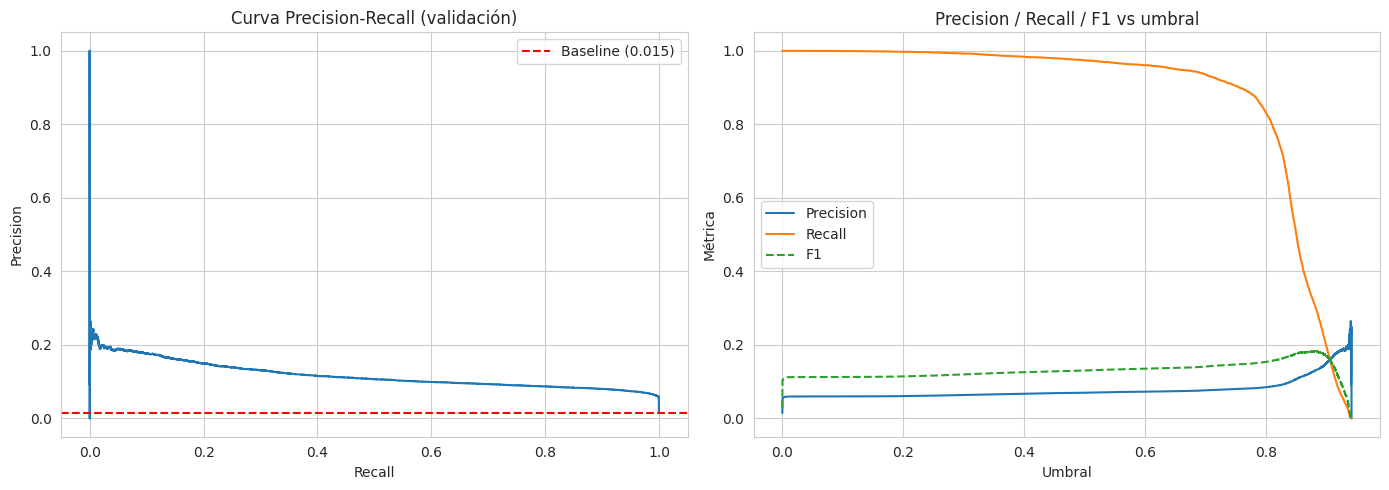

In [ ]:
# Todas las decisiones de umbral se toman sobre val — test se usa UNA SOLA VEZ al final

proba_val_final = MODELO_FINAL.predict_proba(X_val[FEATS_FINAL])[:,1]
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_val, proba_val_final)

# Curva PR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rec_curve, prec_curve)
axes[0].axhline(y_val.mean(), color='red', linestyle='--', label=f'Baseline ({y_val.mean():.3f})')
axes[0].set(title='Curva Precision-Recall (validación)', xlabel='Recall', ylabel='Precision')
axes[0].legend()

f1_arr  = 2*prec_curve*rec_curve / (prec_curve+rec_curve+1e-9)
axes[1].plot(thr_curve, prec_curve[:-1], label='Precision')
axes[1].plot(thr_curve, rec_curve[:-1],  label='Recall')
axes[1].plot(thr_curve, f1_arr[:-1],     label='F1', linestyle='--')
axes[1].set(title='Precision / Recall / F1 vs umbral', xlabel='Umbral', ylabel='Métrica')
axes[1].legend()
plt.tight_layout()
plt.savefig('figuras/curva_pr.png', dpi=150)
plt.show()

In [ ]:
# Comparación de 5 umbrales con criterio operacional
from sklearn.metrics import roc_curve as roc_curve_fn

def umbral_para_recall(rec_arr, thr_arr, target):
    """Umbral más alto que garantiza al menos el recall objetivo."""
    idx = np.where(rec_arr[:-1] >= target)[0]
    return thr_arr[idx[-1]] if len(idx) else None

def umbral_para_precision(prec_arr, thr_arr, target):
    """Umbral más bajo que garantiza al menos la precision objetivo."""
    idx = np.where(prec_arr[:-1] >= target)[0]
    return thr_arr[idx[0]] if len(idx) else None

fpr_v, tpr_v, thr_roc = roc_curve_fn(y_val, proba_val_final)
thr_youden  = thr_roc[np.argmax(tpr_v - fpr_v)]
thr_f1_max  = thr_curve[np.argmax(f1_arr[:-1])]
thr_r50     = umbral_para_recall(rec_curve, thr_curve, 0.50)
thr_r70     = umbral_para_recall(rec_curve, thr_curve, 0.70)
thr_p30     = umbral_para_precision(prec_curve, thr_curve, 0.30)

umbrales = {
    'Default (0.50)':       0.50,
    'F1 máximo':            thr_f1_max,
    'Recall ≥ 50%':         thr_r50,
    'Recall ≥ 70%':         thr_r70,
    'Youden (max TPR-FPR)': thr_youden,
}

filas = []
for nombre, thr in umbrales.items():
    if thr is None:
        continue
    pred = (proba_val_final >= thr).astype(int)
    cm   = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    filas.append({
        'Criterio':  nombre,
        'Umbral':    round(thr, 4),
        'Recall':    round(recall_score(y_val, pred), 4),
        'Precision': round(precision_score(y_val, pred, zero_division=0), 4),
        'F1':        round(f1_score(y_val, pred), 4),
        'TP': tp, 'FN': fn, 'FP': fp
    })

tabla_umbrales = pd.DataFrame(filas)
print(tabla_umbrales.to_string(index=False))

# ── Selección del umbral de reporte ──────────────────────────────────────────
# El modelo opera como rankeador: la cobertura real se controla con N en el
# Top-N diario (sección 11), no con el umbral global.
# Se selecciona F1 máximo como umbral de reporte — punto neutro estándar que
# permite comparar métricas entre modelos sin sesgar hacia recall ni precision.
UMBRAL_FINAL = thr_f1_max
print(f'\nUmbral de reporte seleccionado: F1 máximo = {UMBRAL_FINAL:.4f}')
print('NOTA: en operación este umbral no se usa directamente.')
print('La cobertura real se gestiona con el sistema Top-N diario (ver sección 11).')

            Criterio  Umbral  Recall  Precision     F1   TP   FN     FP
      Default (0.50)  0.5000  0.9741     0.0697 0.1301 9541  254 127380
           F1 máximo  0.8810  0.3085     0.1302 0.1831 3022 6773  20189
        Recall ≥ 50%  0.8503  0.5001     0.1063 0.1754 4898 4897  41168
        Recall ≥ 70%  0.8301  0.7001     0.0930 0.1642 6857 2938  66869
Youden (max TPR-FPR)  0.4515  0.9796     0.0686 0.1282 9595  200 130257

Umbral de reporte seleccionado: F1 máximo = 0.8810
NOTA: en operación este umbral no se usa directamente.
La cobertura real se gestiona con el sistema Top-N diario (ver sección 11).


In [ ]:
# ── Limpieza de RAM antes de evaluación final ─────────────────────────────
# En este punto ya no necesitamos los datos de entrenamiento ni los modelos
# intermedios — solo el modelo final y los conjuntos val/test

# Eliminar conjuntos de entrenamiento
for var in ['X_us', 'y_us', 'X_us_ord', 'y_us_ord', 'X_us_tune', 'y_us_tune']:
    if var in dir():
        exec(f'del {var}')

# Eliminar modelos intermedios — conservar solo el final
modelos_intermedios = [n for n in mejores_pipes if n != 'LightGBM']
for nombre in modelos_intermedios:
    if nombre in mejores_pipes:
        del mejores_pipes[nombre]

# Eliminar df completo — ya tenemos X_val, y_val, X_test, y_test
if 'df' in dir():
    del df

gc.collect()
monitor_memoria()
print('RAM liberada. Variables conservadas: MODELO_FINAL, FEATS_FINAL, UMBRAL_FINAL')
print(f'X_val: {X_val.shape} | X_test: {X_test.shape}')

RAM total: 13.6 GB | Usada: 11.8 GB | Libre: 1.5 GB (88.8%)
RAM liberada. Variables conservadas: MODELO_FINAL, FEATS_FINAL, UMBRAL_FINAL
X_val: (673440, 32) | X_test: (2610480, 32)


## 10. Evaluación final en test (una sola vez)

In [ ]:
# Test nunca fue tocado durante el desarrollo — simula producción real
proba_test_final = MODELO_FINAL.predict_proba(X_test[FEATS_FINAL])[:,1]
pred_test_final  = (proba_test_final >= UMBRAL_FINAL).astype(int)

cm_test = confusion_matrix(y_test, pred_test_final)
tn, fp, fn, tp = cm_test.ravel()

print(f'=== Evaluación final en TEST (umbral={UMBRAL_FINAL:.4f}) ===')
print(f'ROC-AUC:   {roc_auc_score(y_test, proba_test_final):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, proba_test_final):.4f}')
print(f'Recall:    {recall_score(y_test, pred_test_final):.4f}')
print(f'Precision: {precision_score(y_test, pred_test_final, zero_division=0):.4f}')
print(f'F1:        {f1_score(y_test, pred_test_final):.4f}')
print(f'\nMatriz de confusión:')
print(f'  TN={tn:,}  FP={fp:,}')
print(f'  FN={fn:,}  TP={tp:,}')
print(f'\nAccidentes reales en test:   {tp+fn:,}')
print(f'Accidentes detectados (TP):  {tp:,} ({tp/(tp+fn):.1%})')
print(f'Accidentes perdidos (FN):    {fn:,}')
print(f'Falsas alarmas (FP):         {fp:,} ({fp/(fp+tn):.1%} de horas sin accidente)')

=== Evaluación final en TEST (umbral=0.8810) ===
ROC-AUC:   0.9223
PR-AUC:    0.1157
Recall:    0.4193
Precision: 0.1150
F1:        0.1805

Matriz de confusión:
  TN=2,437,733  FP=131,878
  FN=23,731  TP=17,138

Accidentes reales en test:   40,869
Accidentes detectados (TP):  17,138 (41.9%)
Accidentes perdidos (FN):    23,731
Falsas alarmas (FP):         131,878 (5.1% de horas sin accidente)


In [ ]:
# Estabilidad validación vs test
proba_val_thr = (proba_val_final >= UMBRAL_FINAL).astype(int)
comparacion = pd.DataFrame({
    'Validación': {
        'ROC-AUC': roc_auc_score(y_val, proba_val_final),
        'PR-AUC':  average_precision_score(y_val, proba_val_final),
        'Recall':  recall_score(y_val, proba_val_thr),
        'Precision': precision_score(y_val, proba_val_thr, zero_division=0),
    },
    'Test': {
        'ROC-AUC': roc_auc_score(y_test, proba_test_final),
        'PR-AUC':  average_precision_score(y_test, proba_test_final),
        'Recall':  recall_score(y_test, pred_test_final),
        'Precision': precision_score(y_test, pred_test_final, zero_division=0),
    }
}).round(4)
print(comparacion)
print('\nEstabilidad val→test confirma ausencia de sobreajuste.')

           Validación    Test
ROC-AUC        0.9278  0.9223
PR-AUC         0.1172  0.1157
Recall         0.3085  0.4193
Precision      0.1302  0.1150

Estabilidad val→test confirma ausencia de sobreajuste.


## 11. Caso de uso — Sistema de alertas Secretaría de Movilidad

In [ ]:
# 11.1 Sistema Top-N diario — ranking de celdas barrio×hora por riesgo
# La Secretaría no usa un umbral global: prioriza las N celdas más riesgosas cada día

# Reconstruir df_test_op desde parquet — df fue eliminado para liberar RAM
df_aux = pd.read_parquet(
    'checkpoints/df_features.parquet',
    columns=['TW', 'BARRIO', 'target']
)
df_test_op = df_aux[df_aux['TW'] >= FECHA_TEST].copy().reset_index(drop=True)
del df_aux
gc.collect()

df_test_op['proba']  = proba_test_final
df_test_op['fecha']  = df_test_op['TW'].dt.date
df_test_op['hora']   = df_test_op['TW'].dt.hour

print(f'df_test_op: {df_test_op.shape}')

def evaluar_top_n_diario(df_op, n):
    """
    Evalúa la estrategia de emitir las N alertas más riesgosas por día.

    Args:
        df_op (DataFrame): dataset operativo con proba, target y fecha.
        n (int): número de alertas diarias.
    Returns:
        dict con métricas operativas.
    """
    df_op = df_op.copy()
    df_op['rank_dia'] = df_op.groupby('fecha')['proba'].rank(method='first', ascending=False)
    top = df_op[df_op['rank_dia'] <= n]
    return {
        'N alertas/día': n,
        'Precision Top-N': round(top['target'].mean(), 4),
        'Recall capturado': round(top['target'].sum() / df_op['target'].sum(), 4),
        'Alertas anuales': len(top),
        'Accidentes anticipados': int(top['target'].sum())
    }

tabla_top_n = pd.DataFrame([evaluar_top_n_diario(df_test_op, n) for n in [10, 30, 50, 100]])
print('--- Sistema de alertas Top-N diario ---')
print(tabla_top_n.to_string(index=False))

df_test_op: (2610480, 6)
--- Sistema de alertas Top-N diario ---
 N alertas/día  Precision Top-N  Recall capturado  Alertas anuales  Accidentes anticipados
            10           0.1748            0.0156             3650                     638
            30           0.1679            0.0450            10950                    1838
            50           0.1577            0.0704            18250                    2878
           100           0.1468            0.1311            36500                    5358


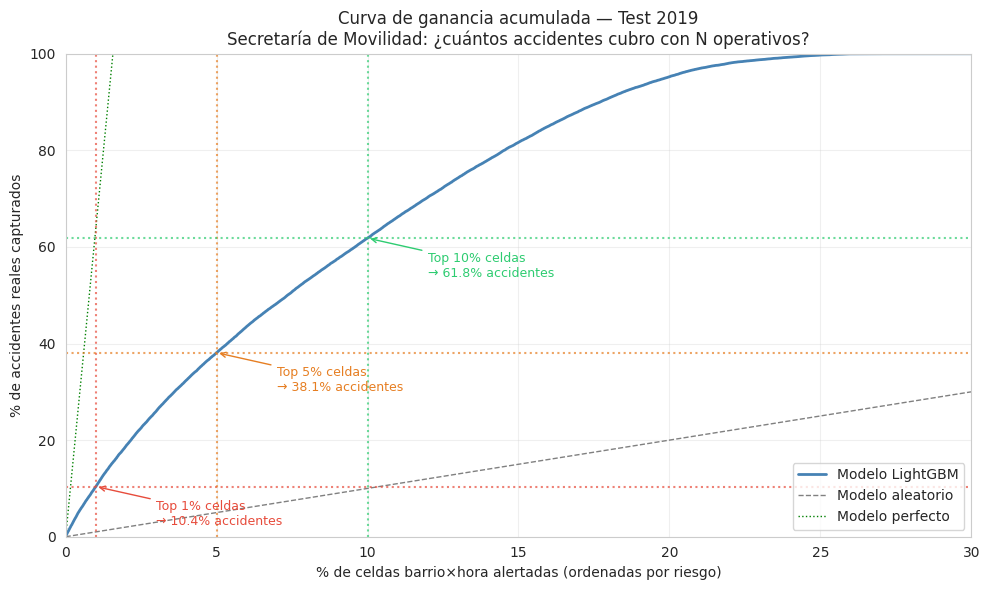

--- Puntos operacionales clave ---
Top   1% celdas (26,104 alertas/año) → 10.4% accidentes capturados
Top   2% celdas (52,209 alertas/año) → 18.8% accidentes capturados
Top   5% celdas (130,524 alertas/año) → 38.1% accidentes capturados
Top  10% celdas (261,048 alertas/año) → 61.8% accidentes capturados
Top  20% celdas (522,096 alertas/año) → 95.2% accidentes capturados


In [ ]:
# Curva de ganancia acumulada — caso de uso operacional
# Responde: ¿qué % de accidentes reales cubro si alerto las N celdas más riesgosas?

df_test_op = df_test_op.sort_values('proba', ascending=False).reset_index(drop=True)

total_accidentes = df_test_op['target'].sum()
total_celdas     = len(df_test_op)

# Calcular ganancia acumulada
df_test_op['accidentes_acum'] = df_test_op['target'].cumsum()
df_test_op['pct_celdas']      = (df_test_op.index + 1) / total_celdas * 100
df_test_op['pct_accidentes']  = df_test_op['accidentes_acum'] / total_accidentes * 100

# Modelo aleatorio — línea base
x_random = [0, 100]
y_random  = [0, 100]

fig, ax = plt.subplots(figsize=(10, 6))

# Curva del modelo
ax.plot(df_test_op['pct_celdas'], df_test_op['pct_accidentes'],
        color='steelblue', linewidth=2, label='Modelo LightGBM')

# Línea aleatoria
ax.plot(x_random, y_random,
        color='gray', linewidth=1, linestyle='--', label='Modelo aleatorio')

# Línea ideal
ax.plot([0, total_accidentes/total_celdas*100, 100], [0, 100, 100],
        color='green', linewidth=1, linestyle=':', label='Modelo perfecto')

# Marcar puntos operacionales clave
for pct_celdas, color in [(1, '#e74c3c'), (5, '#e67e22'), (10, '#2ecc71')]:
    idx = int(total_celdas * pct_celdas / 100)
    pct_acc = df_test_op.loc[idx, 'pct_accidentes']
    ax.axvline(x=pct_celdas, color=color, linestyle=':', alpha=0.7)
    ax.axhline(y=pct_acc,    color=color, linestyle=':', alpha=0.7)
    ax.annotate(
        f'Top {pct_celdas}% celdas\n→ {pct_acc:.1f}% accidentes',
        xy=(pct_celdas, pct_acc),
        xytext=(pct_celdas + 2, pct_acc - 8),
        fontsize=9, color=color,
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_xlabel('% de celdas barrio×hora alertadas (ordenadas por riesgo)')
ax.set_ylabel('% de accidentes reales capturados')
ax.set_title('Curva de ganancia acumulada — Test 2019\n'
             'Secretaría de Movilidad: ¿cuántos accidentes cubro con N operativos?')
ax.legend(loc='lower right')
ax.set_xlim(0, 30)  # zoom en el rango operacional relevante
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figuras/curva_ganancia_acumulada.png', dpi=150)
plt.show()

# Tabla resumen de puntos clave
print('--- Puntos operacionales clave ---')
for pct in [1, 2, 5, 10, 20]:
    idx     = int(total_celdas * pct / 100)
    n_alertas = idx
    pct_acc = df_test_op.loc[min(idx, len(df_test_op)-1), 'pct_accidentes']
    print(f'Top {pct:3}% celdas ({n_alertas:,} alertas/año) → {pct_acc:.1f}% accidentes capturados')

Rango probabilidades: 0.750 — 0.943


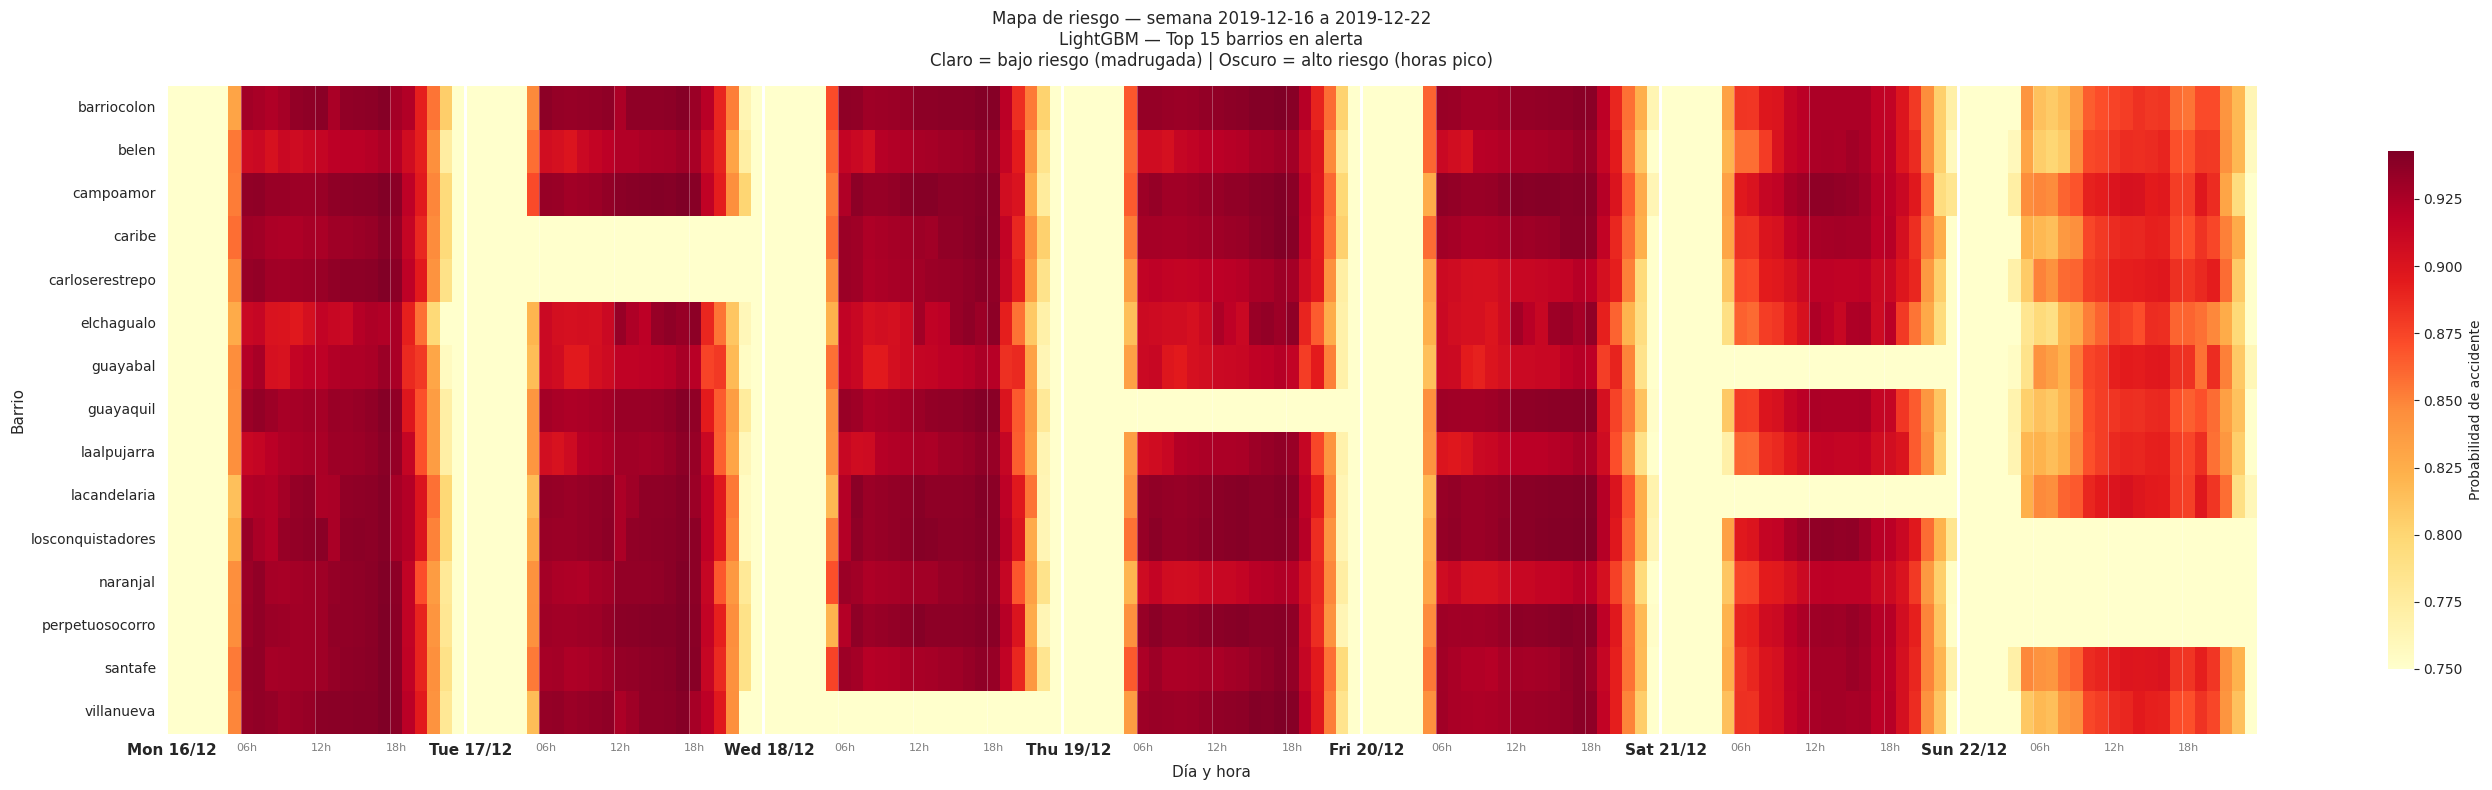

In [ ]:
# 11.2 Heatmap barrio × día-hora — semana del 16 al 22 de diciembre de 2019
# Muestra cuándo y dónde concentrar operativos durante la última semana del año
# Eje X: 7 días × 24 horas = 168 columnas ordenadas cronológicamente
# Eje Y: Top 15 barrios por probabilidad promedio de accidente en la semana

semana = df_test_op[
    (df_test_op['TW'] >= '2019-12-16') &
    (df_test_op['TW'] <  '2019-12-23')
].copy()

# Clave de ordenación: fecha completa + hora (garantiza orden cronológico real)
semana['fecha_completa'] = semana['TW'].dt.strftime('%Y-%m-%d')
semana['dia_label']      = semana['TW'].dt.strftime('%a %d/%m')
semana['dia_hora_key']   = semana['fecha_completa'] + ' ' + semana['hora'].astype(str).str.zfill(2)
semana['dia_hora_label'] = semana['dia_label'] + ' ' + semana['hora'].astype(str).str.zfill(2) + 'h'

# Mapeo key → label para ordenar correctamente
key_to_label = semana.drop_duplicates('dia_hora_key').set_index('dia_hora_key')['dia_hora_label'].to_dict()
cols_ordenadas = sorted(key_to_label.keys())
labels_ordenados = [key_to_label[k] for k in cols_ordenadas]

# Top 15 barrios por probabilidad promedio en la semana
top_barrios = semana.groupby('BARRIO')['proba'].mean().nlargest(15).index

# Pivot con keys ordenadas como columnas
pivot_semana = (
    semana[semana['BARRIO'].isin(top_barrios)]
    .pivot_table(index='BARRIO', columns='dia_hora_key', values='proba', aggfunc='mean')
)[cols_ordenadas]

# Renombrar columnas a labels legibles
pivot_semana.columns = labels_ordenados

vmin = 0.75
vmax = pivot_semana.values.max()
print(f'Rango probabilidades: {vmin:.3f} — {vmax:.3f}')

fig, ax = plt.subplots(figsize=(28, 8))
sns.heatmap(
    pivot_semana, cmap='YlOrRd', ax=ax,
    linewidths=0.0,
    vmin=vmin, vmax=vmax,
    cbar_kws={'label': 'Probabilidad de accidente', 'shrink': 0.8}
)
ax.set_title(
    'Mapa de riesgo — semana 2019-12-16 a 2019-12-22\n'
    'LightGBM — Top 15 barrios en alerta\n'
    'Claro = bajo riesgo (madrugada) | Oscuro = alto riesgo (horas pico)',
    fontsize=12, pad=15
)
ax.set_xlabel('Día y hora', fontsize=11)
ax.set_ylabel('Barrio', fontsize=11)

# Una etiqueta por día en medianoche — evita saturar el eje X con 168 labels
# Etiquetas: nombre del día en medianoche + horas cada 6h
ticks_dia_pos    = [i for i, c in enumerate(pivot_semana.columns) if c.endswith('00h')]
ticks_dia_labels = [c.replace(' 00h', '') for c in pivot_semana.columns if c.endswith('00h')]

ticks_hora_pos    = [i for i, c in enumerate(pivot_semana.columns)
                     if any(c.endswith(h) for h in ['06h', '12h', '18h'])]
ticks_hora_labels = [c.split(' ')[-1].replace('h', 'h')
                     for c in pivot_semana.columns
                     if any(c.endswith(h) for h in ['06h', '12h', '18h'])]

# Combinar todos los ticks
todos_pos    = ticks_dia_pos    + ticks_hora_pos
todos_labels = ticks_dia_labels + ticks_hora_labels

# Ordenar por posición
todos = sorted(zip(todos_pos, todos_labels), key=lambda x: x[0])
todos_pos, todos_labels = zip(*todos)

ax.set_xticks([t + 0.5 for t in todos_pos])
ax.set_xticklabels(
    todos_labels, rotation=0, fontsize=9,
    # Días en negrita, horas en gris
    **{}
)

# Colorear etiquetas: días en negro, horas en gris
for tick, label in zip(ax.get_xticklabels(), todos_labels):
    if any(label == d for d in ticks_dia_labels):
        tick.set_fontweight('bold')
        tick.set_fontsize(11)
    else:
        tick.set_color('gray')
        tick.set_fontsize(8)

# Líneas blancas separando días
for pos in ticks_dia_pos:
    ax.axvline(x=pos, color='white', linewidth=2)

# Líneas grises tenues separando bloques de 6h
for pos in ticks_hora_pos:
    ax.axvline(x=pos, color='white', linewidth=0.5, alpha=0.4)

# Líneas blancas verticales separando cada día
for pos in ticks_pos:
    ax.axvline(x=pos, color='white', linewidth=2)

plt.tight_layout()
plt.savefig('figuras/heatmap_riesgo_semana.png', dpi=150, bbox_inches='tight')
plt.show()

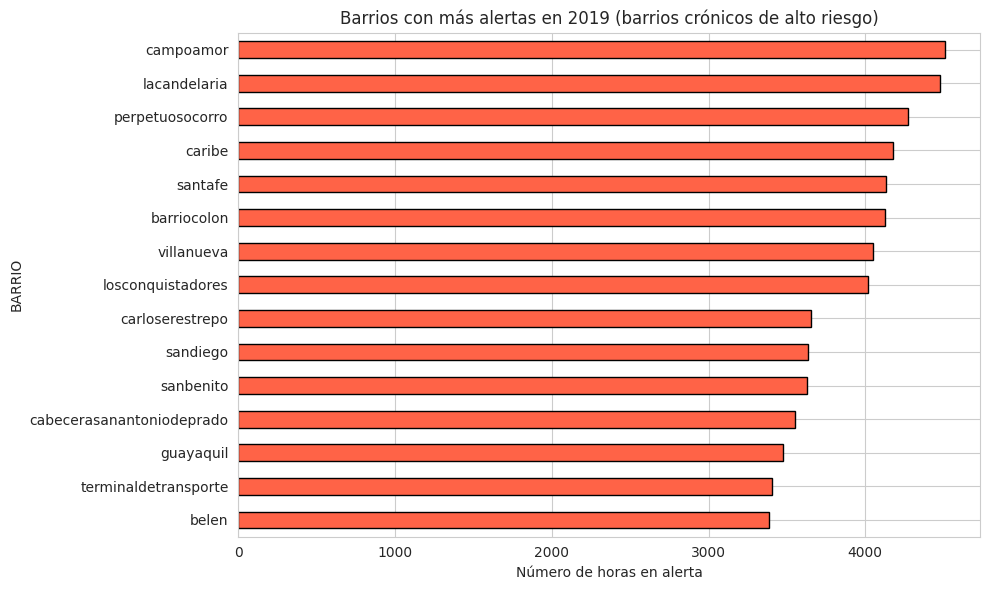

In [ ]:
# 11.3 Barrios crónicos de alto riesgo en 2019
top_cronicos = (
    df_test_op[df_test_op['proba'] >= UMBRAL_FINAL]['BARRIO']
    .value_counts()
    .head(15)
)
fig, ax = plt.subplots(figsize=(10, 6))
top_cronicos.sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.set_title('Barrios con más alertas en 2019 (barrios crónicos de alto riesgo)')
ax.set_xlabel('Número de horas en alerta')
plt.tight_layout()
plt.savefig('figuras/barrios_cronicos.png', dpi=150)
plt.show()

## 12. Limitaciones, variables externas y trabajo futuro

LIMITACIONES DEL MODELO


---


1. Sesgos en datos: solo accidentes reportados oficialmente; los no reportados no existen para el modelo.
2. Concept drift: patrones 2017-2019 pueden no ser válidos en años posteriores (cambios urbanos, pandemia).
3. Interpretabilidad: LightGBM es caja negra; dificulta explicar decisiones a autoridades.
4. Resolución geográfica: barrio, no intersección. Dos calles del mismo barrio reciben la misma alerta.
5. Falsas alarmas: ~28% de horas sin accidente generan alerta → riesgo de fatiga operativa.
6. Historial dominante: incluso sin barrio_freq, hist_accidentes_barrio captura la misma señal estructural.



---


VARIABLES EXTERNAS QUE MEJORARÍAN EL MODELO

- Eventos urbanos: partidos de fútbol (Clásico Paisa), conciertos, ferias, marchas.
- Obras viales activas: cierres y desvíos concentran tráfico.
- Flujo vehicular en tiempo real: congestión es el predictor más directo.
- Densidad poblacional y vehicular: DANE + RUNT.
- Festivos locales no capturados por el calendario nacional.
- Estado del pavimento e iluminación nocturna por barrio.



---


TRABAJO FUTURO

Corto plazo:  reentrenamiento periódico, ajuste dinámico del umbral, incorporación de eventos.
Mediano plazo: desagregación a nivel intersección, pipeline automatizado de alertas semanales.
Largo plazo:   extensión a otros municipios del Valle de Aburrá, integración con sistemas de tráfico.

## 13. Versiones de librerías

In [ ]:
import sklearn, lightgbm, xgboost, imblearn
print(f'pandas:      {pd.__version__}')
print(f'numpy:       {np.__version__}')
print(f'scikit-learn:{sklearn.__version__}')
print(f'lightgbm:    {lightgbm.__version__}')
print(f'xgboost:     {xgboost.__version__}')
print(f'imbalanced:  {imblearn.__version__}')
print(f'holidays:    {holidays.__version__}')

pandas:      2.2.2
numpy:       2.0.2
scikit-learn:1.6.1
lightgbm:    4.6.0
xgboost:     3.2.0
imbalanced:  0.14.1
holidays:    0.95
